# 📦 Sales & Demand Forecasting System
**Dataset:** Superstore Sales (Kaggle)  
**Models:** Facebook Prophet + XGBoost (Dual-Model Approach)  
**Goal:** Forecast weekly sales, identify seasonal patterns, and deliver actionable business insights

| Model | Purpose |
|---|---|
| **Prophet** | Trend analysis, seasonality decomposition, holiday effects, long-term forecasting |
| **XGBoost** | Short-term week-over-week accuracy, spike detection, lag-based prediction |

## 1. Imports & Configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from prophet.make_holidays import make_holidays_df
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

## 2. Load & Clean Data

In [3]:
df = pd.read_csv('../data/superstore_sales.csv', encoding='latin-1')

df.drop_duplicates(inplace=True)
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])
df = df.sort_values('Order Date').reset_index(drop=True)

print(f"Shape      : {df.shape}")
print(f"Date range : {df['Order Date'].min().date()} → {df['Order Date'].max().date()}")
print(f"Categories : {df['Category'].unique()}")
print(f"Regions    : {df['Region'].unique()}")
missing = df.isnull().sum()
print(f"\nMissing values:\n{missing[missing > 0] if missing.any() else 'None'}")
df.head()

Shape      : (9994, 21)
Date range : 2014-01-03 → 2017-12-30
Categories : <StringArray>
['Office Supplies', 'Furniture', 'Technology']
Length: 3, dtype: str
Regions    : <StringArray>
['Central', 'East', 'South', 'West']
Length: 4, dtype: str

Missing values:
None


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,7981,CA-2014-103800,2014-01-03,2014-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,740,CA-2014-112326,2014-01-04,2014-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
2,741,CA-2014-112326,2014-01-04,2014-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
3,742,CA-2014-112326,2014-01-04,2014-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
4,1760,CA-2014-141817,2014-01-05,2014-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


## 3. Feature Engineering — Seasonality & Time Features
Explicit time-based features extracted from Order Date.  
Used directly in XGBoost as input features, and visible in EDA for business understanding.  
Prophet handles seasonality internally via its own decomposition engine.

In [4]:
df['year']         = df['Order Date'].dt.year
df['month']        = df['Order Date'].dt.month
df['quarter']      = df['Order Date'].dt.quarter
df['day_of_week']  = df['Order Date'].dt.dayofweek
df['week_of_year'] = df['Order Date'].dt.isocalendar().week.astype(int)
df['is_weekend']   = df['day_of_week'].isin([5, 6]).astype(int)

season_map = {12:'Winter', 1:'Winter',  2:'Winter',
               3:'Spring', 4:'Spring',  5:'Spring',
               6:'Summer', 7:'Summer',  8:'Summer',
               9:'Fall',  10:'Fall',   11:'Fall'}
df['season'] = df['month'].map(season_map)
df['is_q4']  = (df['quarter'] == 4).astype(int)

print("Engineered features:")
print(df[['Order Date','year','month','quarter','week_of_year',
          'is_weekend','season','is_q4']].head(8).to_string(index=False))

Engineered features:
Order Date  year  month  quarter  week_of_year  is_weekend season  is_q4
2014-01-03  2014      1        1             1           0 Winter      0
2014-01-04  2014      1        1             1           1 Winter      0
2014-01-04  2014      1        1             1           1 Winter      0
2014-01-04  2014      1        1             1           1 Winter      0
2014-01-05  2014      1        1             1           1 Winter      0
2014-01-06  2014      1        1             2           0 Winter      0
2014-01-06  2014      1        1             2           0 Winter      0
2014-01-06  2014      1        1             2           0 Winter      0


## 4. Holiday & Retail Event Setup
US public holidays and key retail events passed to Prophet as special regressors.  
The same event dates are used to create binary flag features for XGBoost.

In [5]:
years = [2014, 2015, 2016, 2017, 2018]

# Built-in US public holidays
us_holidays = make_holidays_df(year_list=years, country='US')

# Retail-specific events
extra_events = pd.DataFrame({
    'holiday': [
        'black_friday','black_friday','black_friday','black_friday',
        'cyber_monday','cyber_monday','cyber_monday','cyber_monday',
        'back_to_school','back_to_school','back_to_school','back_to_school',
    ],
    'ds': pd.to_datetime([
        '2014-11-28','2015-11-27','2016-11-25','2017-11-24',
        '2014-12-01','2015-11-30','2016-11-28','2017-11-27',
        '2014-08-01','2015-08-01','2016-08-01','2017-08-01',
    ]),
    'lower_window': [-1,-1,-1,-1,  0, 0, 0, 0, -14,-14,-14,-14],
    'upper_window': [ 3, 3, 3, 3,  2, 2, 2, 2,  14, 14, 14, 14],
})

all_holidays = pd.concat([us_holidays, extra_events], ignore_index=True)
print(f"US public holidays     : {len(us_holidays)}")
print(f"Retail-specific events : {len(extra_events)}")
print(f"Total holiday records  : {len(all_holidays)}")

US public holidays     : 55
Retail-specific events : 12
Total holiday records  : 67


## 5. Exploratory Data Analysis

In [6]:
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()
daily_sales['rolling_30'] = daily_sales['Sales'].rolling(30).mean()
daily_category_sales = df.groupby(['Order Date','Category'])['Sales'].sum().reset_index()

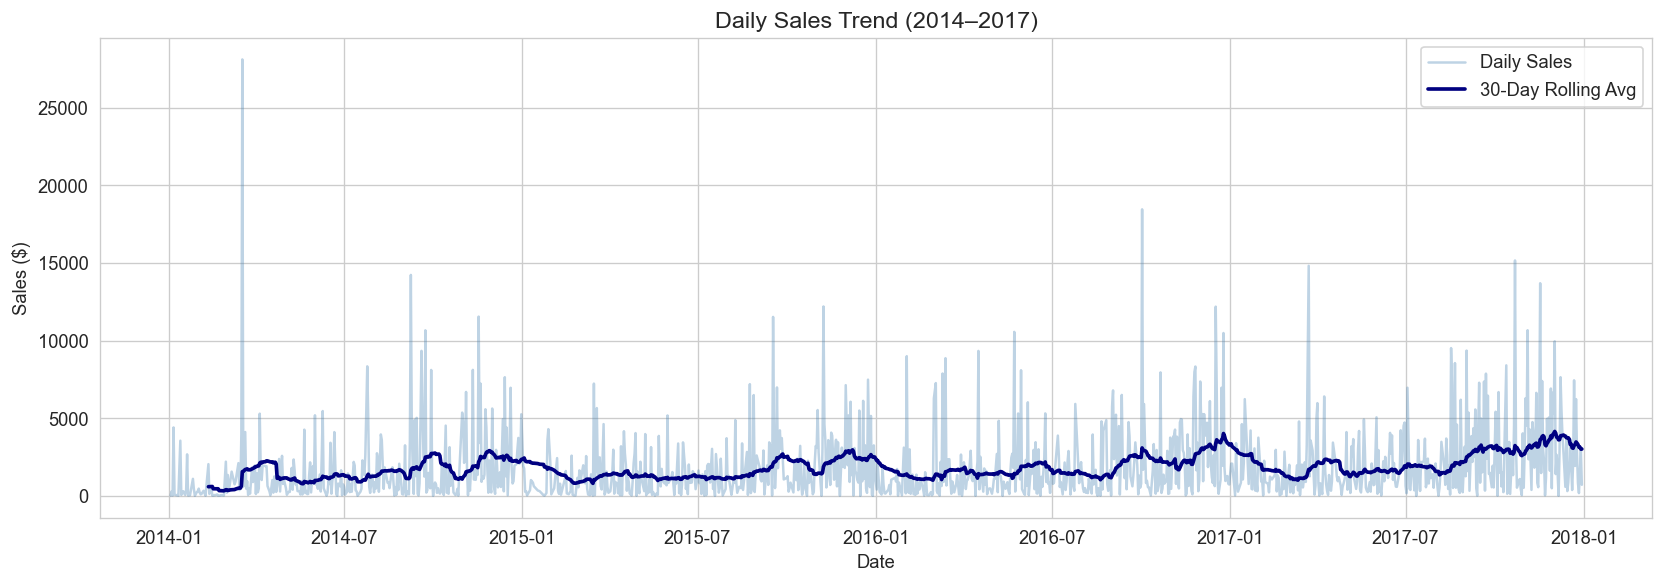

In [7]:
# Daily Sales Trend
plt.figure(figsize=(14, 5))
plt.plot(daily_sales['Order Date'], daily_sales['Sales'],
         alpha=0.35, color='steelblue', label='Daily Sales')
plt.plot(daily_sales['Order Date'], daily_sales['rolling_30'],
         color='navy', linewidth=2.2, label='30-Day Rolling Avg')
plt.title('Daily Sales Trend (2014–2017)', fontsize=14)
plt.xlabel('Date'); plt.ylabel('Sales ($)')
plt.legend(); plt.tight_layout(); plt.show()

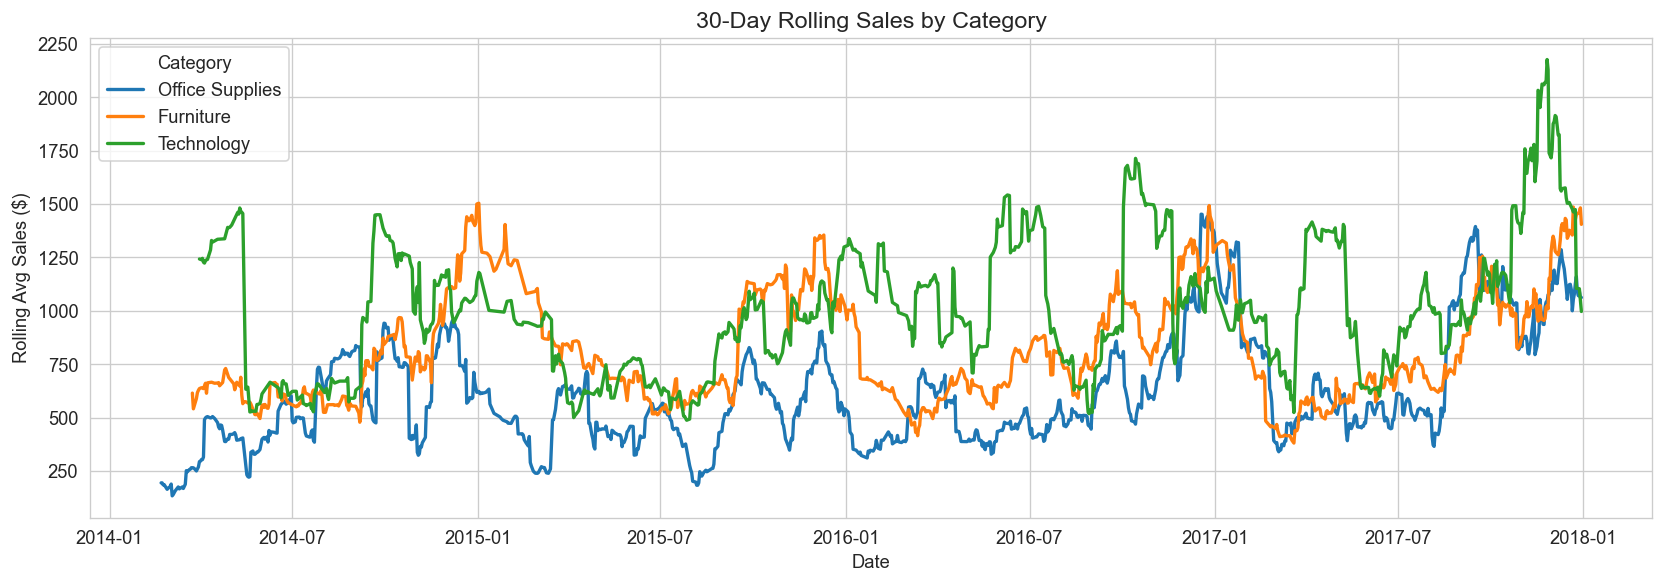

In [8]:
# Rolling Average by Category
daily_category_sales['rolling_30'] = (
    daily_category_sales.groupby('Category')['Sales']
    .transform(lambda x: x.rolling(30).mean())
)
plt.figure(figsize=(14, 5))
sns.lineplot(data=daily_category_sales, x='Order Date',
             y='rolling_30', hue='Category', linewidth=2)
plt.title('30-Day Rolling Sales by Category', fontsize=14)
plt.xlabel('Date'); plt.ylabel('Rolling Avg Sales ($)')
plt.tight_layout(); plt.show()

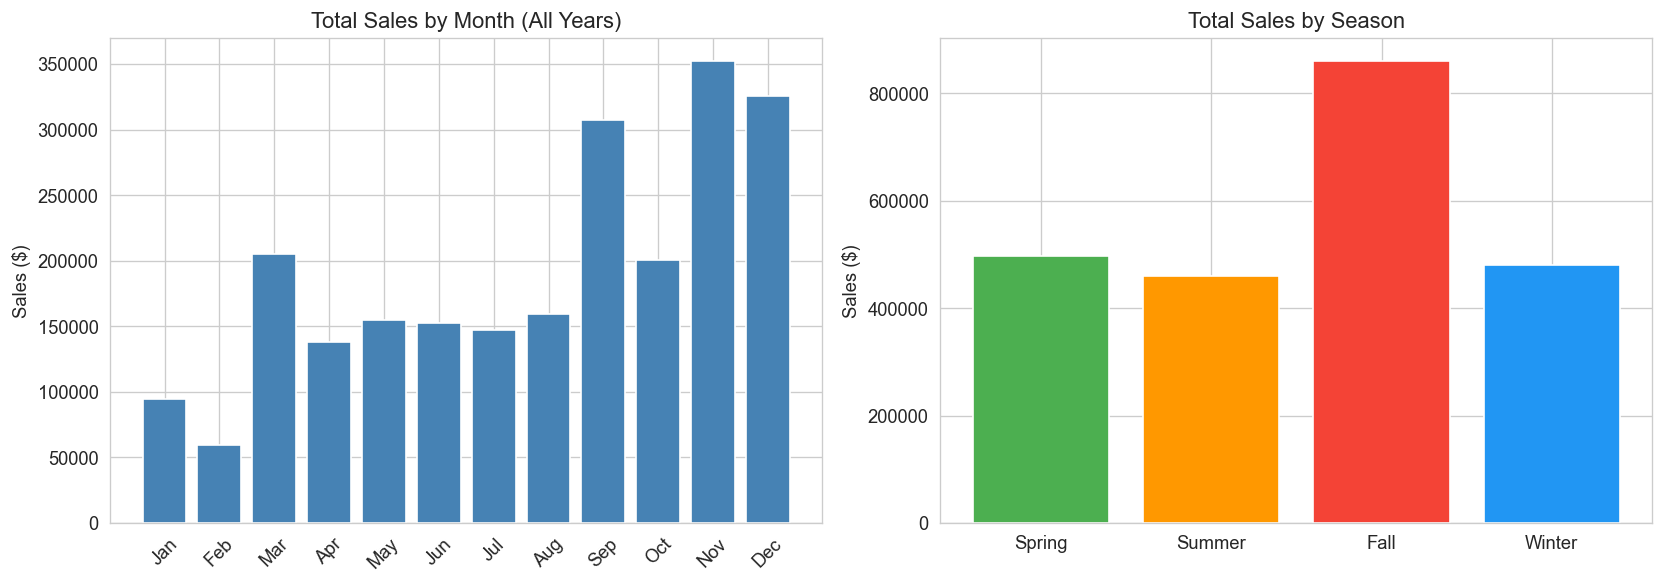

In [9]:
# Monthly & Seasonal breakdown
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

month_sales = df.groupby('month')['Sales'].sum().reset_index()
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
axes[0].bar(month_sales['month'], month_sales['Sales'],
            color='steelblue', edgecolor='white')
axes[0].set_xticks(range(1,13))
axes[0].set_xticklabels(month_names, rotation=45)
axes[0].set_title('Total Sales by Month (All Years)')
axes[0].set_ylabel('Sales ($)')

season_sales = df.groupby('season')['Sales'].sum().reset_index()
season_order = ['Spring','Summer','Fall','Winter']
season_sales['season'] = pd.Categorical(
    season_sales['season'], categories=season_order, ordered=True)
season_sales = season_sales.sort_values('season')
axes[1].bar(season_sales['season'], season_sales['Sales'],
            color=['#4CAF50','#FF9800','#F44336','#2196F3'], edgecolor='white')
axes[1].set_title('Total Sales by Season')
axes[1].set_ylabel('Sales ($)')
plt.tight_layout(); plt.show()

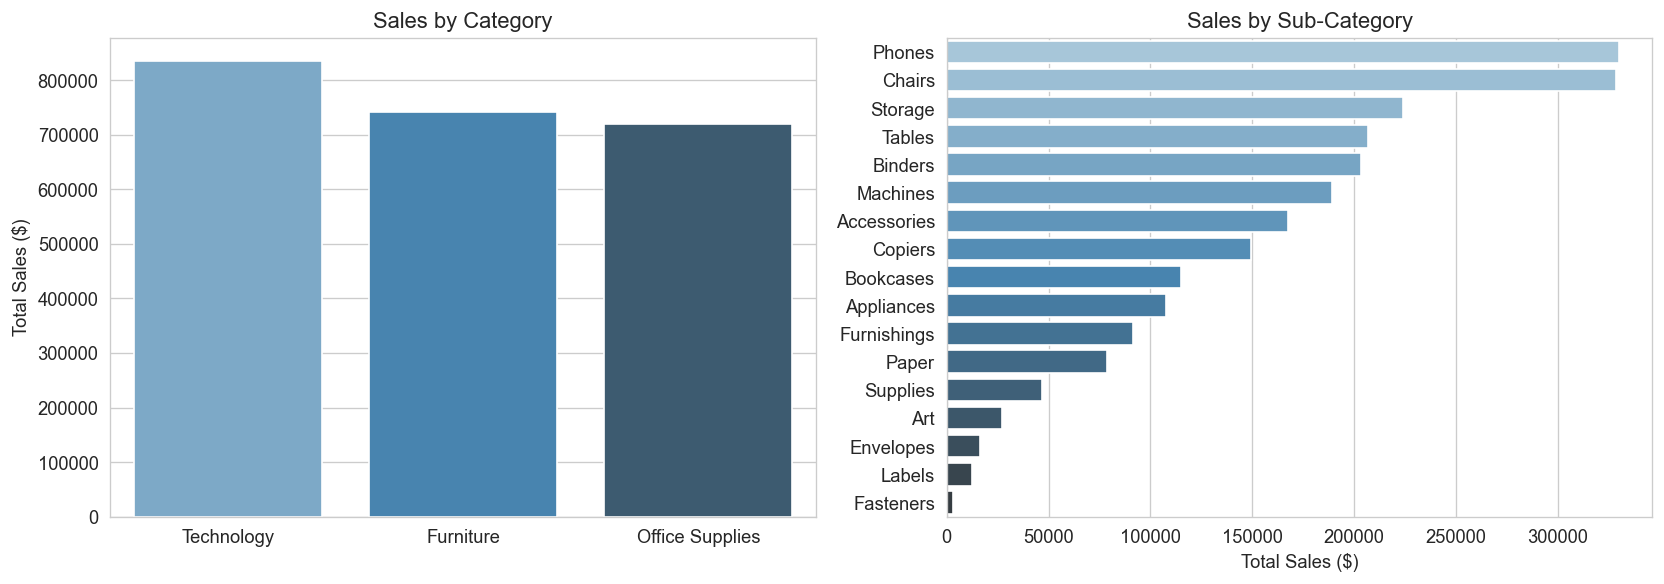

In [10]:
# Category & Sub-Category
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat_sales = df.groupby('Category')['Sales'].sum().reset_index().sort_values('Sales', ascending=False)
sns.barplot(x='Category', y='Sales', data=cat_sales, ax=axes[0], palette='Blues_d')
axes[0].set_title('Sales by Category')
axes[0].set_ylabel('Total Sales ($)'); axes[0].set_xlabel('')

sub_sales = df.groupby('Sub-Category')['Sales'].sum().reset_index().sort_values('Sales', ascending=False)
sns.barplot(x='Sales', y='Sub-Category', data=sub_sales, ax=axes[1], palette='Blues_d')
axes[1].set_title('Sales by Sub-Category')
axes[1].set_xlabel('Total Sales ($)'); axes[1].set_ylabel('')
plt.tight_layout(); plt.show()

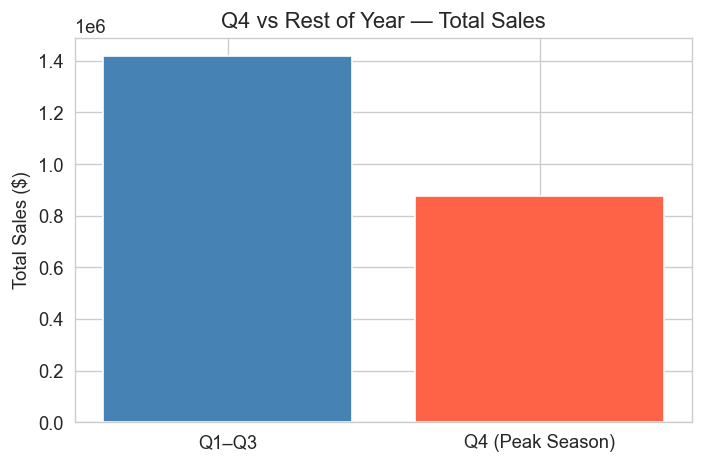

Q4 accounts for 38.2% of annual revenue


In [11]:
# Q4 vs rest of year
q4_sales  = df[df['is_q4'] == 1]['Sales'].sum()
non_sales = df[df['is_q4'] == 0]['Sales'].sum()

plt.figure(figsize=(6, 4))
plt.bar(['Q1–Q3', 'Q4 (Peak Season)'], [non_sales, q4_sales],
        color=['steelblue','tomato'], edgecolor='white')
plt.title('Q4 vs Rest of Year — Total Sales')
plt.ylabel('Total Sales ($)')
plt.tight_layout(); plt.show()
print(f"Q4 accounts for {q4_sales/(q4_sales+non_sales)*100:.1f}% of annual revenue")

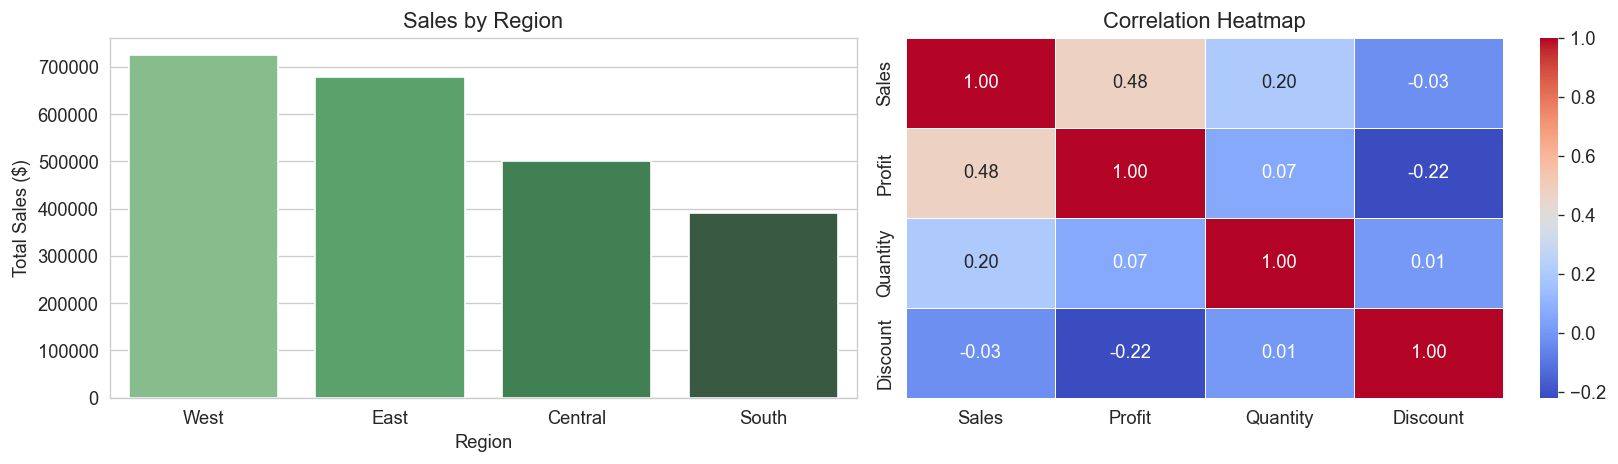

In [12]:
# Regional sales + Correlation heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

region_sales = df.groupby('Region')['Sales'].sum().reset_index().sort_values('Sales', ascending=False)
sns.barplot(x='Region', y='Sales', data=region_sales, palette='Greens_d', ax=axes[0])
axes[0].set_title('Sales by Region')
axes[0].set_xlabel('Region'); axes[0].set_ylabel('Total Sales ($)')

corr = df[['Sales','Profit','Quantity','Discount']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, ax=axes[1])
axes[1].set_title('Correlation Heatmap')
plt.tight_layout(); plt.show()

## 6. Outlier Treatment
IQR-based removal of anomalous days before weekly aggregation.  
Near-zero days (< $100) are excluded as they represent store closures or data gaps.

In [13]:
Q1 = daily_sales['Sales'].quantile(0.25)
Q3 = daily_sales['Sales'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

clean_daily = daily_sales[
    (daily_sales['Sales'] >= 100) &
    (daily_sales['Sales'] <= upper_bound)
].copy()

removed = len(daily_sales) - len(clean_daily)
print(f"Original days : {len(daily_sales)}")
print(f"Cleaned days  : {len(clean_daily)}")
print(f"Removed       : {removed} days ({removed/len(daily_sales)*100:.1f}%)")
print(f"Upper bound   : ${upper_bound:,.2f}")
print(f"New mean      : ${clean_daily['Sales'].mean():,.2f}")
print(f"New median    : ${clean_daily['Sales'].median():,.2f}")

Original days : 1237
Cleaned days  : 1027
Removed       : 210 days (17.0%)
Upper bound   : $5,422.86
New mean      : $1,560.97
New median    : $1,137.34


## 7. Weekly Dataset Preparation

In [14]:
weekly_sales = (
    clean_daily.set_index('Order Date')
    .resample('W')['Sales'].sum()
    .reset_index()
    .rename(columns={'Order Date':'ds', 'Sales':'y'})
)
print(f"Weekly records    : {len(weekly_sales)}")
print(f"Mean weekly sales : ${weekly_sales['y'].mean():,.2f}")
print(f"Std dev           : ${weekly_sales['y'].std():,.2f}")
print(f"Date range        : {weekly_sales['ds'].min().date()} → {weekly_sales['ds'].max().date()}")
weekly_sales.tail()

Weekly records    : 209
Mean weekly sales : $7,670.39
Std dev           : $4,258.62
Date range        : 2014-01-05 → 2017-12-31


,ds,y
204,2017-12-03,8845.1620
205,2017-12-10,10882.8470
206,2017-12-17,10495.9630
207,2017-12-24,9987.2890
208,2017-12-31,8977.8318


## 8. Model 1 — Facebook Prophet
**Role:** Long-term trend analysis, seasonality decomposition, holiday effects, future forecasting  
**Strength:** Interpretable components, business-friendly plots, handles irregular patterns via holiday regressors  
**Limitation:** Smooth curve — designed to capture structural patterns, not short-term spikes

In [15]:
# Test periods
test_start_nonq4 = pd.Timestamp('2017-01-01')
test_end_nonq4   = pd.Timestamp('2017-06-30')
test_start_q4    = pd.Timestamp('2017-10-01')

train_nonq4 = weekly_sales[weekly_sales['ds'] < test_start_nonq4]
test_nonq4  = weekly_sales[(weekly_sales['ds'] >= test_start_nonq4) &
                            (weekly_sales['ds'] <= test_end_nonq4)]
train_q4    = weekly_sales[weekly_sales['ds'] < test_start_q4]
test_q4     = weekly_sales[weekly_sales['ds'] >= test_start_q4]

print(f"Non-Q4 → Train: {len(train_nonq4)} | Test: {len(test_nonq4)} weeks")
print(f"Q4     → Train: {len(train_q4)}    | Test: {len(test_q4)} weeks")

Non-Q4 → Train: 156 | Test: 26 weeks
Q4     → Train: 195    | Test: 14 weeks


In [16]:
def train_prophet(train_df, holidays_df):
    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=0.2,
        n_changepoints=40,
        holidays=holidays_df
    )
    m.fit(train_df)
    return m

def evaluate(y_true, y_pred, label):
    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    smape = np.mean(2 * np.abs(y_true - y_pred) /
                    (np.abs(y_true) + np.abs(y_pred) + 1e-9)) * 100
    pct   = (mae / y_true.mean()) * 100
    print(f"  MAE              : ${mae:,.2f}")
    print(f"  RMSE             : ${rmse:,.2f}")
    print(f"  sMAPE            : {smape:.2f}%")
    print(f"  MAE as % of mean : {pct:.1f}%")
    return {'label':label,'MAE':mae,'RMSE':rmse,'sMAPE':smape,'MAE_pct':pct}

results = []  # collect all model results for final comparison

19:16:31 - cmdstanpy - INFO - Chain [1] start processing
19:16:31 - cmdstanpy - INFO - Chain [1] done processing


=== Prophet — Non-Q4 (Jan–Jun 2017) ===
  MAE              : $2,677.66
  RMSE             : $3,186.77
  sMAPE            : 34.54%
  MAE as % of mean : 32.6%


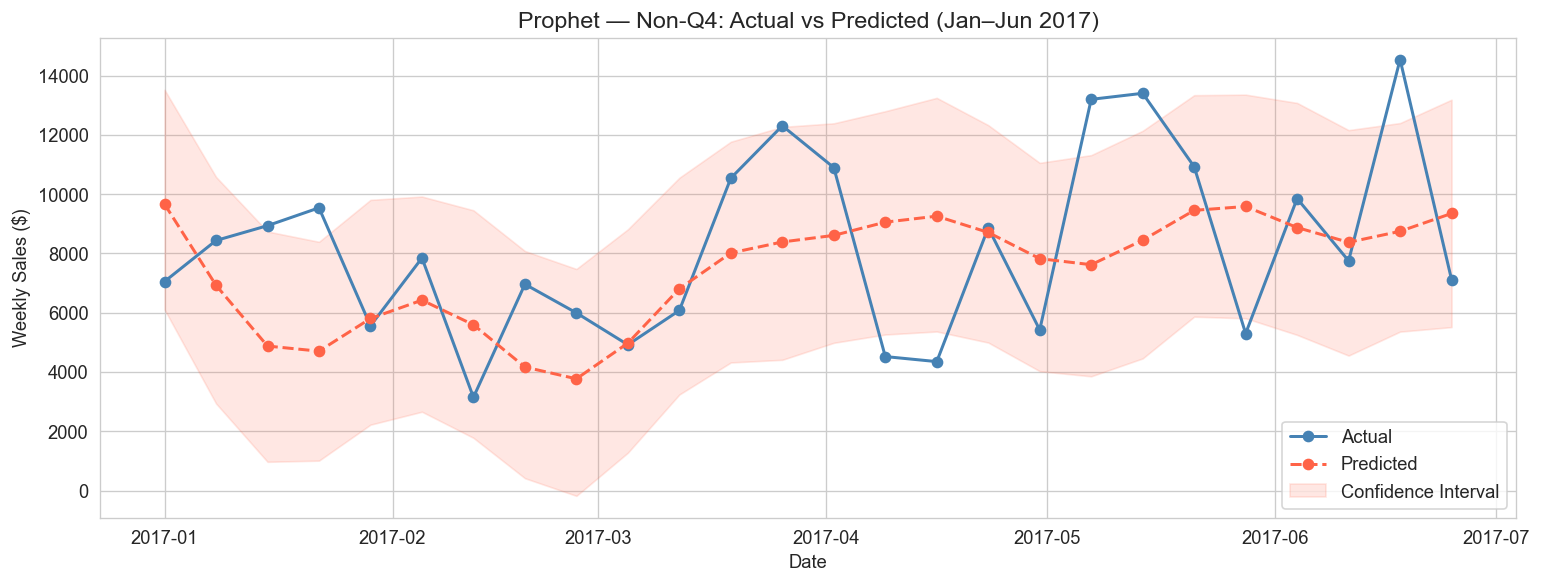

In [17]:
# Prophet — Non-Q4
p_nonq4 = train_prophet(train_nonq4, all_holidays)
fc_p_nonq4 = p_nonq4.predict(test_nonq4[['ds']])
y_true_nq  = test_nonq4['y'].values
y_pred_p_nq = fc_p_nonq4['yhat'].values

print("=== Prophet — Non-Q4 (Jan–Jun 2017) ===")
results.append(evaluate(y_true_nq, y_pred_p_nq, 'Prophet — Non-Q4'))

plt.figure(figsize=(13, 5))
plt.plot(test_nonq4['ds'], y_true_nq,
         marker='o', color='steelblue', linewidth=1.8, label='Actual')
plt.plot(test_nonq4['ds'], y_pred_p_nq,
         marker='o', linestyle='--', color='tomato', linewidth=1.8, label='Predicted')
plt.fill_between(test_nonq4['ds'],
                 fc_p_nonq4['yhat_lower'].values,
                 fc_p_nonq4['yhat_upper'].values,
                 alpha=0.15, color='tomato', label='Confidence Interval')
plt.title('Prophet — Non-Q4: Actual vs Predicted (Jan–Jun 2017)', fontsize=14)
plt.xlabel('Date'); plt.ylabel('Weekly Sales ($)')
plt.legend(); plt.tight_layout(); plt.show()

19:16:46 - cmdstanpy - INFO - Chain [1] start processing
19:16:46 - cmdstanpy - INFO - Chain [1] done processing


=== Prophet — Q4 (Oct–Dec 2017) ===
  MAE              : $4,022.23
  RMSE             : $4,720.85
  sMAPE            : 37.39%
  MAE as % of mean : 36.3%


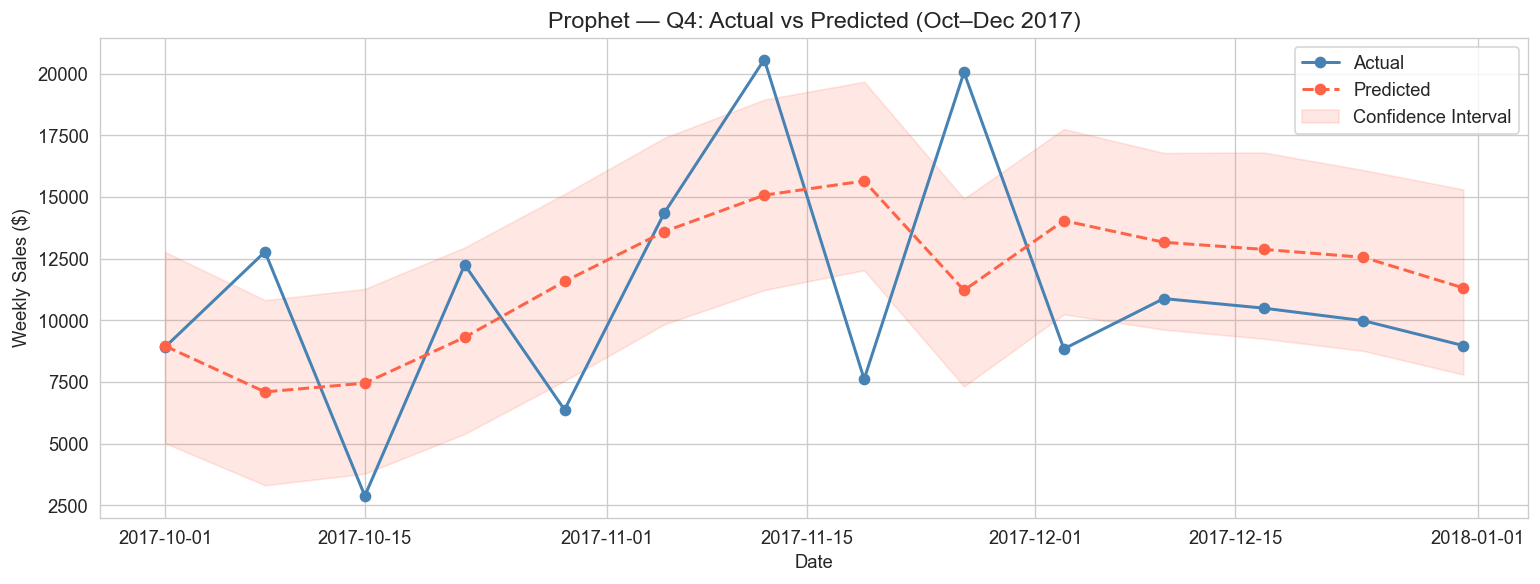

In [18]:
# Prophet — Q4
p_q4 = train_prophet(train_q4, all_holidays)
fc_p_q4    = p_q4.predict(test_q4[['ds']])
y_true_q   = test_q4['y'].values
y_pred_p_q = fc_p_q4['yhat'].values

print("=== Prophet — Q4 (Oct–Dec 2017) ===")
results.append(evaluate(y_true_q, y_pred_p_q, 'Prophet — Q4'))

plt.figure(figsize=(13, 5))
plt.plot(test_q4['ds'], y_true_q,
         marker='o', color='steelblue', linewidth=1.8, label='Actual')
plt.plot(test_q4['ds'], y_pred_p_q,
         marker='o', linestyle='--', color='tomato', linewidth=1.8, label='Predicted')
plt.fill_between(test_q4['ds'],
                 fc_p_q4['yhat_lower'].values,
                 fc_p_q4['yhat_upper'].values,
                 alpha=0.15, color='tomato', label='Confidence Interval')
plt.title('Prophet — Q4: Actual vs Predicted (Oct–Dec 2017)', fontsize=14)
plt.xlabel('Date'); plt.ylabel('Weekly Sales ($)')
plt.legend(); plt.tight_layout(); plt.show()

### Prophet Q4 Limitation — Why the Curve Is Smooth
Prophet is designed to model **structural patterns** — trend and seasonality — not individual week-level volatility.

The Q4 spikes are caused by:
- **Black Friday / Cyber Monday** bulk orders concentrated in one or two specific weeks
- **Unpredictable corporate year-end purchasing** — single large orders with no fixed pattern
- **Only 3 prior Q4 seasons** in training data — not enough to learn exact spike magnitudes

The model correctly identifies the Q4 upward direction but cannot match the exact spike magnitude.  
This is expected behaviour — and is why we use XGBoost alongside Prophet for short-term accuracy.

## 9. Model 2 — XGBoost with Lag Features
**Role:** Short-term week-over-week prediction, spike detection  
**Strength:** Learns from recent sales history via lag features — if last week was high, this week likely is too  
**Limitation:** Cannot extrapolate beyond training range; needs recursive forecasting for future predictions

In [19]:
# Build XGBoost feature set from weekly data
xgb_df = weekly_sales.copy()
xgb_df['week_of_year'] = xgb_df['ds'].dt.isocalendar().week.astype(int)
xgb_df['month']        = xgb_df['ds'].dt.month
xgb_df['quarter']      = xgb_df['ds'].dt.quarter
xgb_df['year']         = xgb_df['ds'].dt.year
xgb_df['is_q4']        = (xgb_df['quarter'] == 4).astype(int)

# Lag features — recent sales history
for lag in [1, 2, 3, 4]:
    xgb_df[f'lag_{lag}'] = xgb_df['y'].shift(lag)

# Rolling statistics
xgb_df['rolling_mean_4'] = xgb_df['y'].shift(1).rolling(4).mean()
xgb_df['rolling_std_4']  = xgb_df['y'].shift(1).rolling(4).std()
xgb_df['rolling_mean_8'] = xgb_df['y'].shift(1).rolling(8).mean()

# Holiday flags
black_friday_dates = pd.to_datetime([
    '2014-11-28','2015-11-27','2016-11-25','2017-11-24'])
cyber_monday_dates = pd.to_datetime([
    '2014-12-01','2015-11-30','2016-11-28','2017-11-27'])

def is_near_event(date, event_dates, window=7):
    return int(any(abs((date - d).days) <= window for d in event_dates))

xgb_df['is_black_friday'] = xgb_df['ds'].apply(
    lambda d: is_near_event(d, black_friday_dates))
xgb_df['is_cyber_monday'] = xgb_df['ds'].apply(
    lambda d: is_near_event(d, cyber_monday_dates))

xgb_df = xgb_df.dropna().reset_index(drop=True)

FEATURES = ['week_of_year','month','quarter','year','is_q4',
            'lag_1','lag_2','lag_3','lag_4',
            'rolling_mean_4','rolling_std_4','rolling_mean_8',
            'is_black_friday','is_cyber_monday']

print(f"XGBoost dataset: {len(xgb_df)} weeks after lag creation")
print(f"Features used  : {len(FEATURES)}")
xgb_df[FEATURES + ['y']].tail()

XGBoost dataset: 201 weeks after lag creation
Features used  : 14


,week_of_year,month,quarter,year,is_q4,lag_1,lag_2,lag_3,lag_4,rolling_mean_4,rolling_std_4,rolling_mean_8,is_black_friday,is_cyber_monday,y
196,48,12,4,2017,1,20051.537,7618.848,20571.872,14363.089,15651.33650,6048.522882,12112.819525,0,1,8845.1620
197,49,12,4,2017,1,8845.162,20051.537,7618.848,20571.872,14271.85475,6995.389846,11620.999775,0,0,10882.8470
198,50,12,4,2017,1,10882.847,8845.162,20051.537,7618.848,11849.59850,5631.231129,12620.328275,0,0,10495.9630
199,51,12,4,2017,1,10495.963,10882.847,8845.162,20051.537,12568.87725,5066.093949,12400.713875,0,0,9987.2890
200,52,12,4,2017,1,9987.289,10495.963,10882.847,8845.162,10052.81525,884.694429,12852.075875,0,0,8977.8318


=== XGBoost — Non-Q4 (Jan–Jun 2017) ===
  MAE              : $3,204.65
  RMSE             : $4,014.01
  sMAPE            : 44.32%
  MAE as % of mean : 39.0%


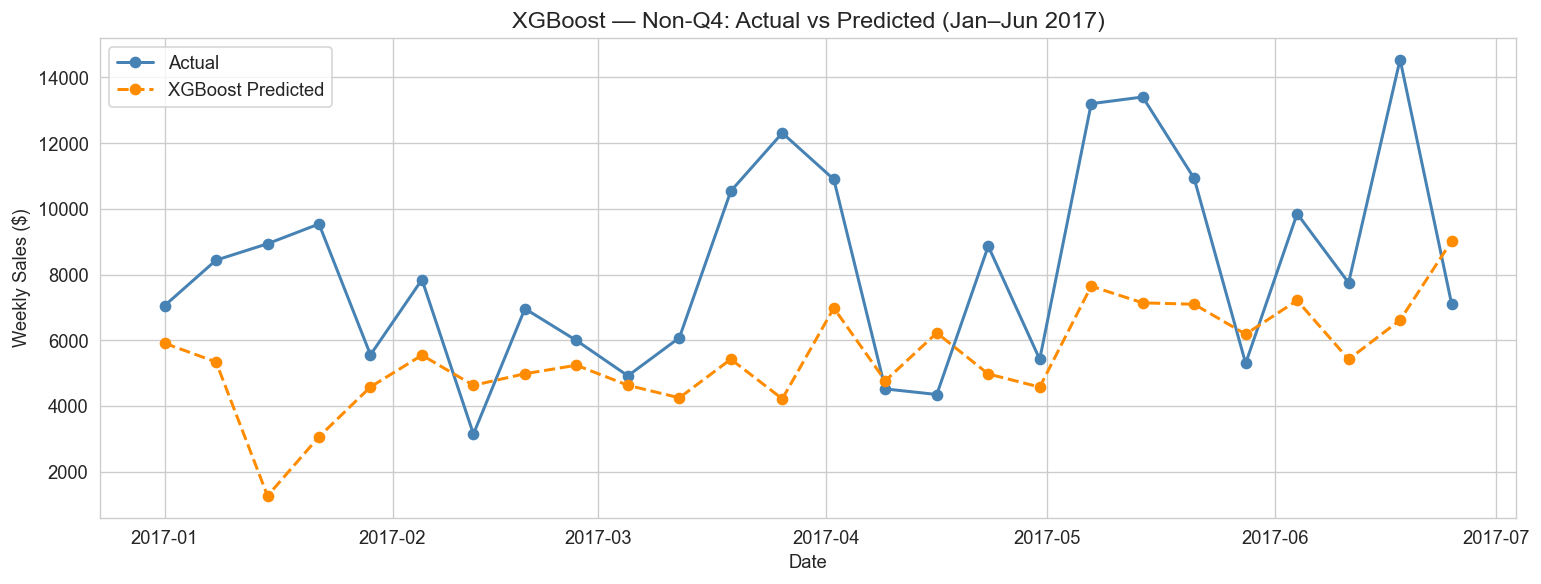

In [20]:
# Non-Q4 test split
test_mask_nq  = (xgb_df['ds'] >= test_start_nonq4) & (xgb_df['ds'] <= test_end_nonq4)
train_mask_nq = xgb_df['ds'] < test_start_nonq4

X_train_nq = xgb_df.loc[train_mask_nq, FEATURES]
y_train_nq = xgb_df.loc[train_mask_nq, 'y']
X_test_nq  = xgb_df.loc[test_mask_nq,  FEATURES]
y_test_nq  = xgb_df.loc[test_mask_nq,  'y']
dates_nq   = xgb_df.loc[test_mask_nq,  'ds']

xgb_nonq4 = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
xgb_nonq4.fit(X_train_nq, y_train_nq,
              eval_set=[(X_test_nq, y_test_nq)],
              verbose=False)

y_pred_x_nq = xgb_nonq4.predict(X_test_nq)

print("=== XGBoost — Non-Q4 (Jan–Jun 2017) ===")
results.append(evaluate(y_test_nq.values, y_pred_x_nq, 'XGBoost — Non-Q4'))

plt.figure(figsize=(13, 5))
plt.plot(dates_nq, y_test_nq.values,
         marker='o', color='steelblue', linewidth=1.8, label='Actual')
plt.plot(dates_nq, y_pred_x_nq,
         marker='o', linestyle='--', color='darkorange', linewidth=1.8, label='XGBoost Predicted')
plt.title('XGBoost — Non-Q4: Actual vs Predicted (Jan–Jun 2017)', fontsize=14)
plt.xlabel('Date'); plt.ylabel('Weekly Sales ($)')
plt.legend(); plt.tight_layout(); plt.show()

=== XGBoost — Q4 (Oct–Dec 2017) ===
  MAE              : $3,649.41
  RMSE             : $5,139.28
  sMAPE            : 35.85%
  MAE as % of mean : 33.0%


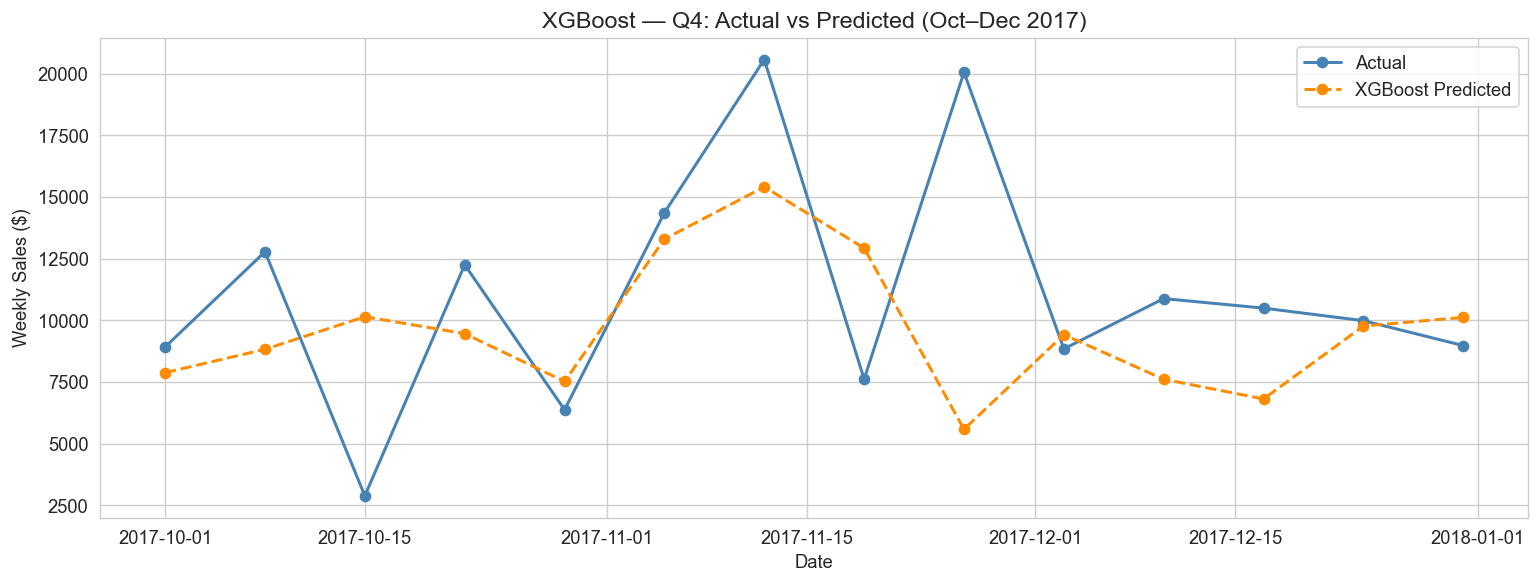

In [21]:
# Q4 test split
test_mask_q  = xgb_df['ds'] >= test_start_q4
train_mask_q = xgb_df['ds'] < test_start_q4

X_train_q = xgb_df.loc[train_mask_q, FEATURES]
y_train_q = xgb_df.loc[train_mask_q, 'y']
X_test_q  = xgb_df.loc[test_mask_q,  FEATURES]
y_test_q  = xgb_df.loc[test_mask_q,  'y']
dates_q   = xgb_df.loc[test_mask_q,  'ds']

xgb_q4 = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
xgb_q4.fit(X_train_q, y_train_q,
           eval_set=[(X_test_q, y_test_q)],
           verbose=False)

y_pred_x_q = xgb_q4.predict(X_test_q)

print("=== XGBoost — Q4 (Oct–Dec 2017) ===")
results.append(evaluate(y_test_q.values, y_pred_x_q, 'XGBoost — Q4'))

plt.figure(figsize=(13, 5))
plt.plot(dates_q, y_test_q.values,
         marker='o', color='steelblue', linewidth=1.8, label='Actual')
plt.plot(dates_q, y_pred_x_q,
         marker='o', linestyle='--', color='darkorange', linewidth=1.8, label='XGBoost Predicted')
plt.title('XGBoost — Q4: Actual vs Predicted (Oct–Dec 2017)', fontsize=14)
plt.xlabel('Date'); plt.ylabel('Weekly Sales ($)')
plt.legend(); plt.tight_layout(); plt.show()

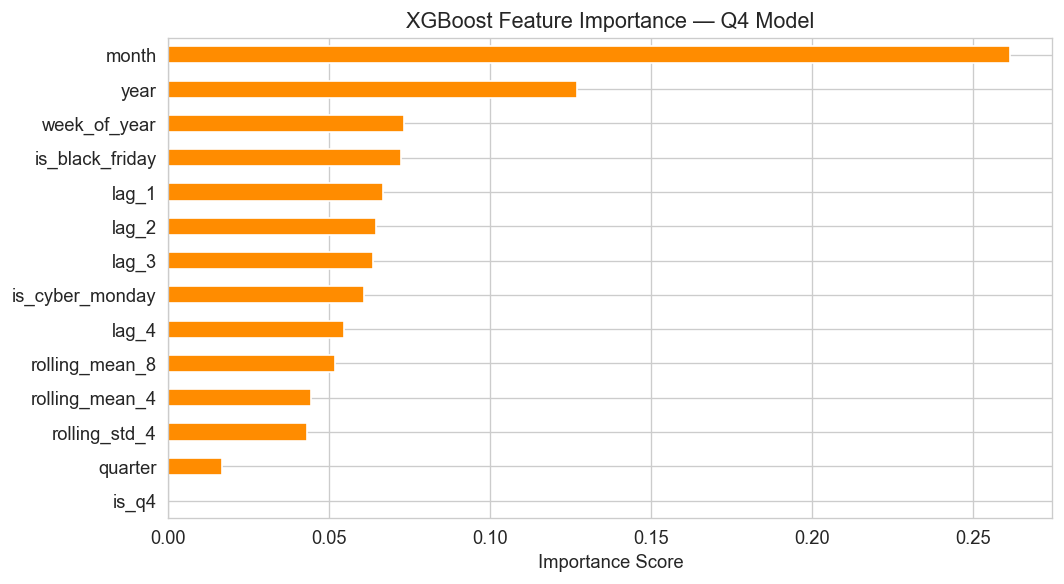

In [22]:
# XGBoost Feature Importance
plt.figure(figsize=(9, 5))
importance = pd.Series(xgb_q4.feature_importances_, index=FEATURES).sort_values(ascending=True)
importance.plot(kind='barh', color='darkorange', edgecolor='white')
plt.title('XGBoost Feature Importance — Q4 Model', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout(); plt.show()

## 10. Model Comparison — Prophet vs XGBoost

                      MAE     RMSE  sMAPE  MAE_pct
label                                             
Prophet — Non-Q4  2677.66  3186.77  34.54    32.61
Prophet — Q4      4022.23  4720.85  37.39    36.33
XGBoost — Non-Q4  3204.65  4014.01  44.32    39.03
XGBoost — Q4      3649.41  5139.28  35.85    32.96


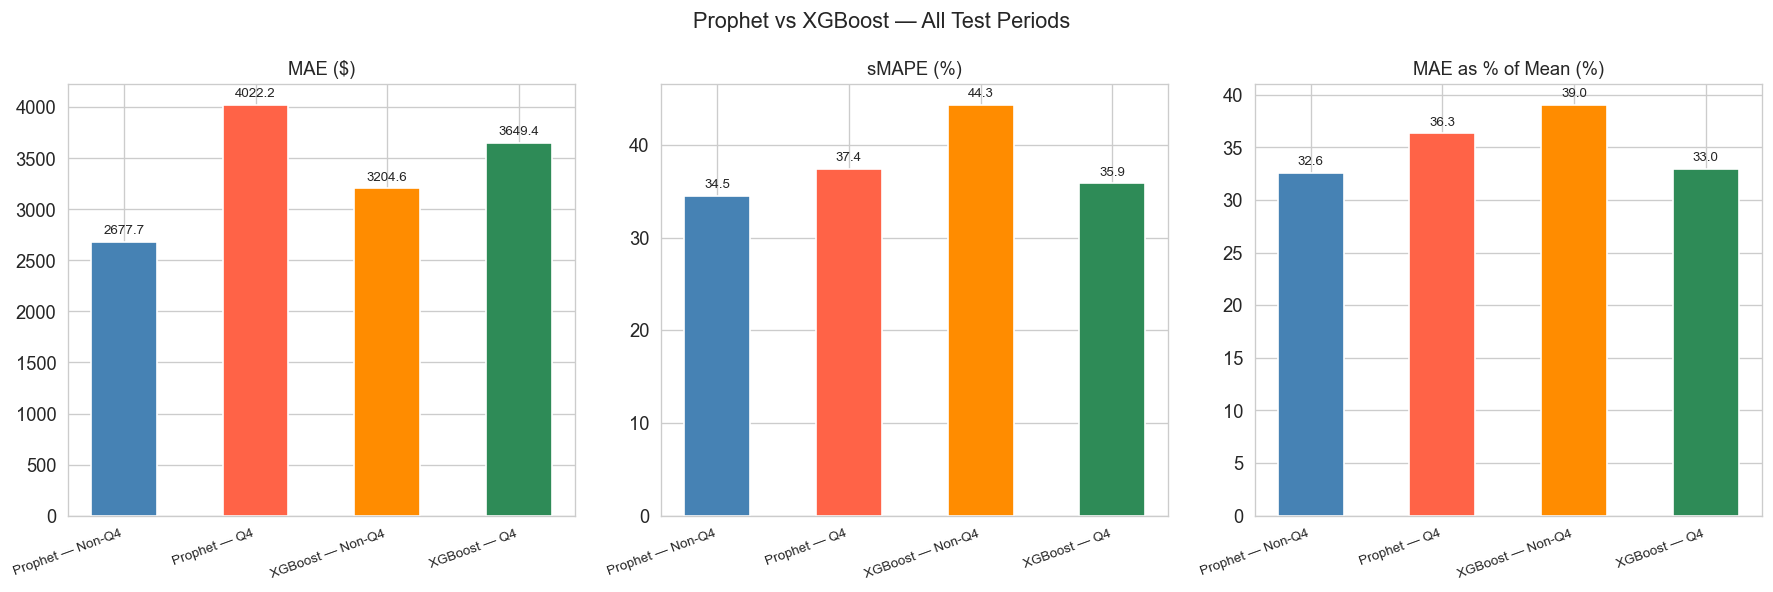

In [23]:
results_df = pd.DataFrame(results).set_index('label')
print(results_df.round(2).to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics   = ['MAE', 'sMAPE', 'MAE_pct']
titles    = ['MAE ($)', 'sMAPE (%)', 'MAE as % of Mean (%)']
colors    = ['steelblue','tomato','darkorange','seagreen']

for ax, m, title in zip(axes, metrics, titles):
    vals  = results_df[m]
    bars  = ax.bar(range(len(vals)), vals.values,
                   color=colors[:len(vals)], edgecolor='white', width=0.5)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(vals.index, rotation=20, ha='right', fontsize=8)
    ax.set_title(title, fontsize=11)
    ax.bar_label(bars, labels=[f'{v:.1f}' for v in vals.values], padding=3, fontsize=8)

plt.suptitle('Prophet vs XGBoost — All Test Periods', fontsize=13)
plt.tight_layout(); plt.show()

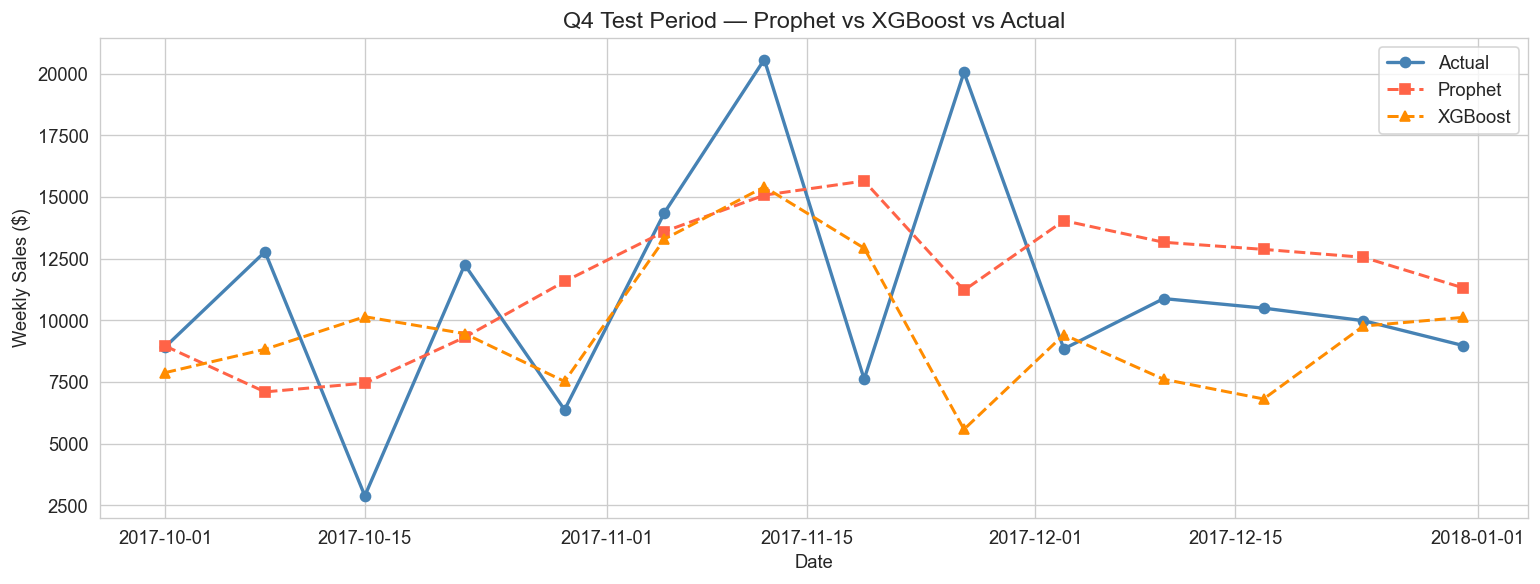

In [24]:
# Side-by-side on the same plot for Q4
plt.figure(figsize=(13, 5))
plt.plot(dates_q, y_test_q.values,
         marker='o', color='steelblue', linewidth=2, label='Actual')
plt.plot(dates_q, y_pred_p_q,
         marker='s', linestyle='--', color='tomato', linewidth=1.8, label='Prophet')
plt.plot(dates_q, y_pred_x_q,
         marker='^', linestyle='--', color='darkorange', linewidth=1.8, label='XGBoost')
plt.title('Q4 Test Period — Prophet vs XGBoost vs Actual', fontsize=14)
plt.xlabel('Date'); plt.ylabel('Weekly Sales ($)')
plt.legend(); plt.tight_layout(); plt.show()

### Comparison Analysis

| Scenario | Better Model | Why |
|---|---|---|
| **Non-Q4 (stable periods)** | Prophet | Captures trend + seasonal baseline cleanly |
| **Q4 (volatile periods)** | XGBoost | Lag features help it react to recent spikes |
| **Future forecasting** | Prophet | XGBoost cannot extrapolate beyond training data |
| **Business explainability** | Prophet | Decomposition plots are non-technical friendly |
| **Spike detection** | XGBoost | Learns from last week's value directly |

**Conclusion:** Neither model is universally better. In production, businesses use both:
- Prophet for **strategic planning** (next quarter, seasonal budgets)
- XGBoost for **operational planning** (next 1–4 weeks, inventory reordering)

### Why No Model Can Fully Solve This

The core limitation is not the model — it is the data itself.
With only 3 years of Q4 history, every spike looks different,
and no pattern is consistent enough for any algorithm to learn.
Even professional forecasting systems at Amazon and Walmart
treat Q4 as a special case requiring external signals —
promotional calendars, ad spend data, and manual analyst adjustments —
none of which are available in this dataset.

## 11. Prophet — Full Forecast & Decomposition
Trained on all available data for the most accurate long-term forward projection.

In [25]:
full_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.2,
    n_changepoints=40,
    holidays=all_holidays
)
full_prophet.fit(weekly_sales)
future   = full_prophet.make_future_dataframe(periods=8, freq='W')
forecast = full_prophet.predict(future)
print(f"Forecast generated up to: {forecast['ds'].max().date()}")

19:17:45 - cmdstanpy - INFO - Chain [1] start processing
19:17:45 - cmdstanpy - INFO - Chain [1] done processing


Forecast generated up to: 2018-02-25


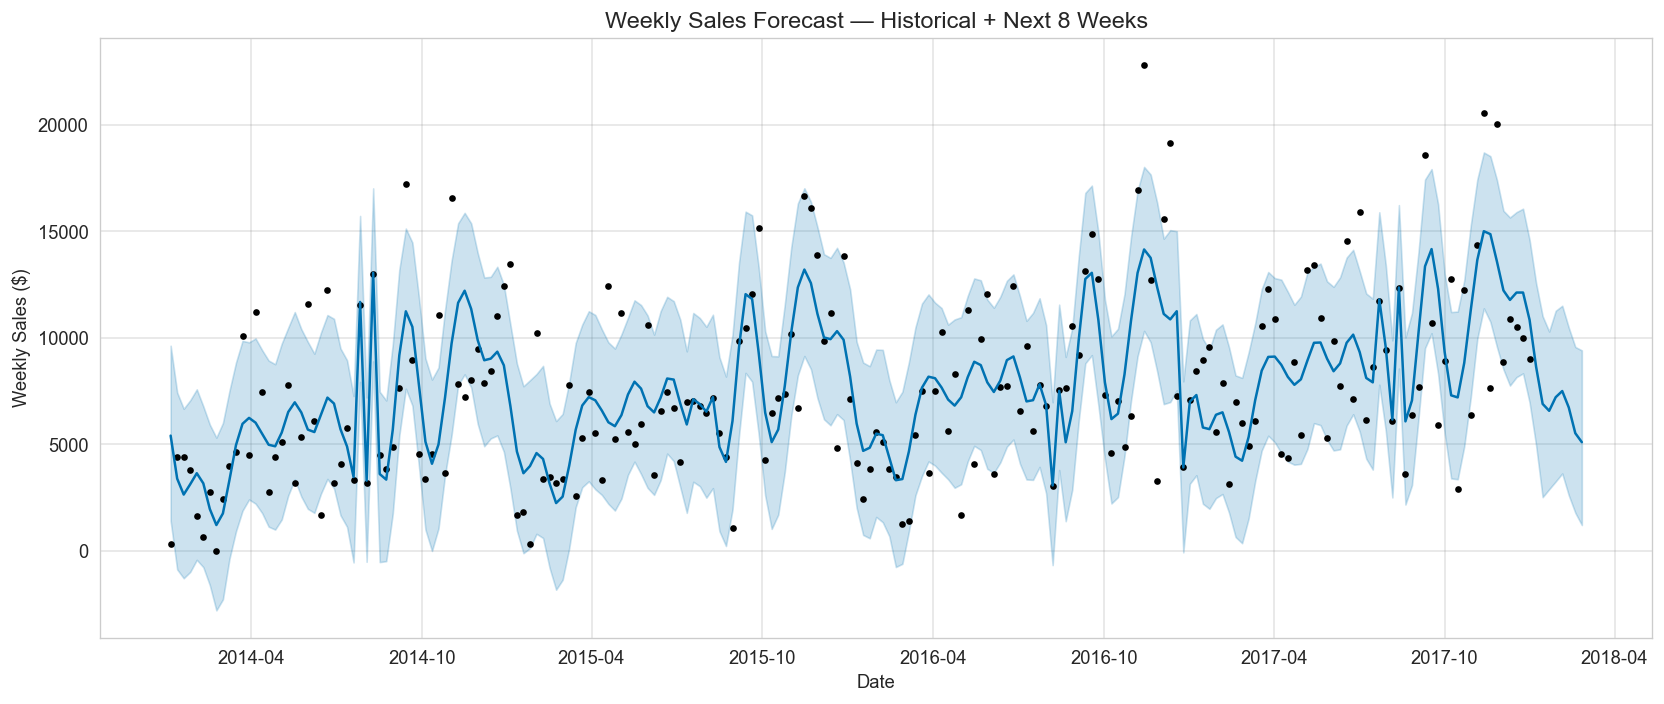

In [26]:
# Full forecast plot
fig = full_prophet.plot(forecast, figsize=(14, 6))
plt.title('Weekly Sales Forecast — Historical + Next 8 Weeks', fontsize=14)
plt.xlabel('Date'); plt.ylabel('Weekly Sales ($)')
plt.tight_layout(); plt.show()

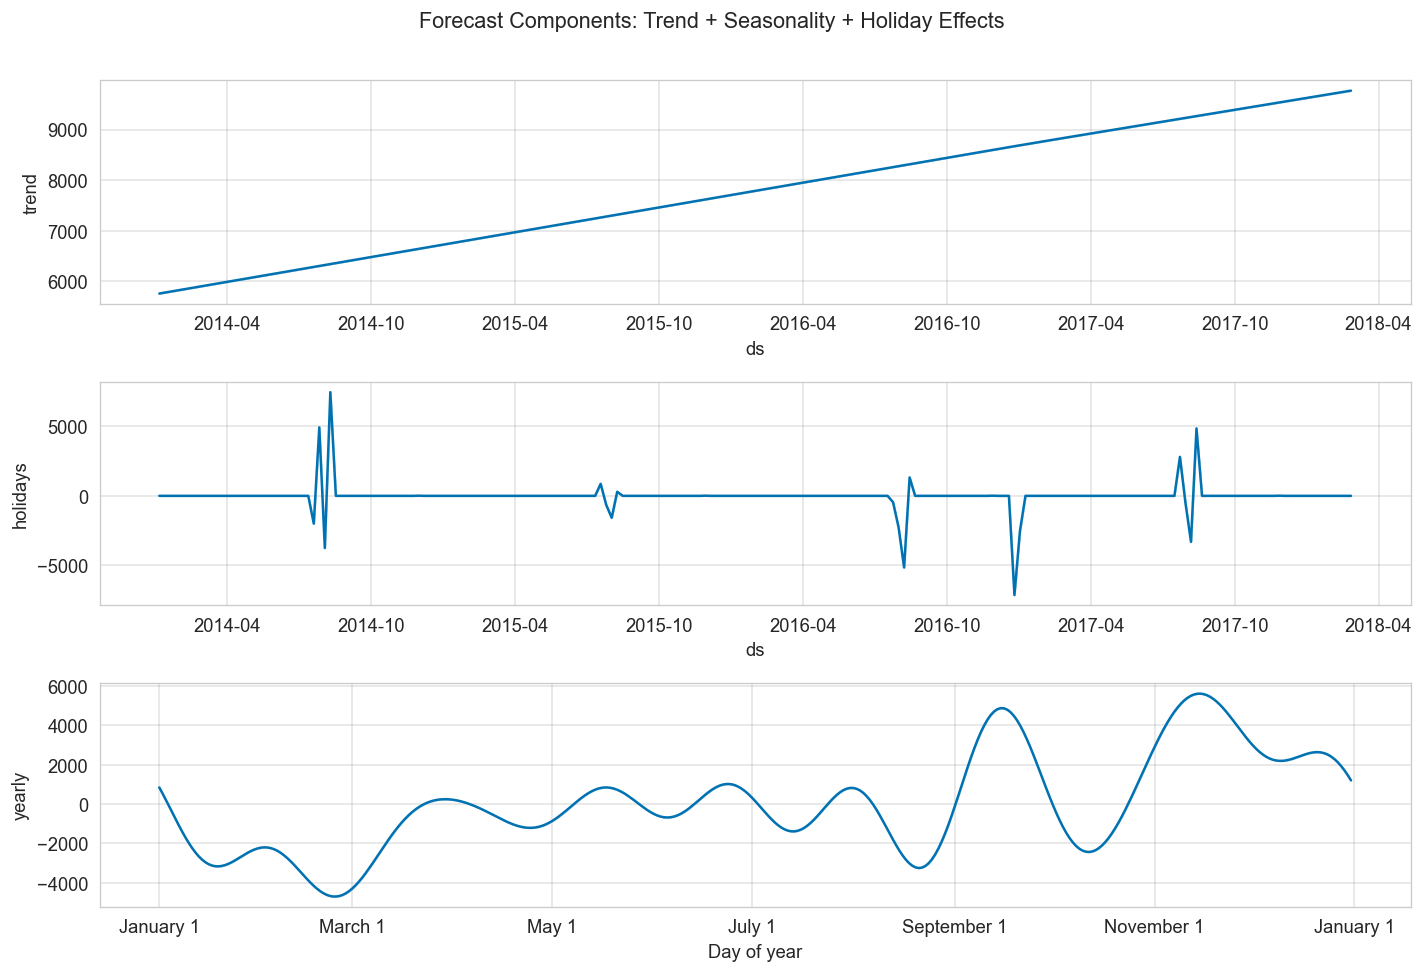

In [27]:
# Components decomposition
fig = full_prophet.plot_components(forecast, figsize=(12, 8))
plt.suptitle('Forecast Components: Trend + Seasonality + Holiday Effects',
             fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

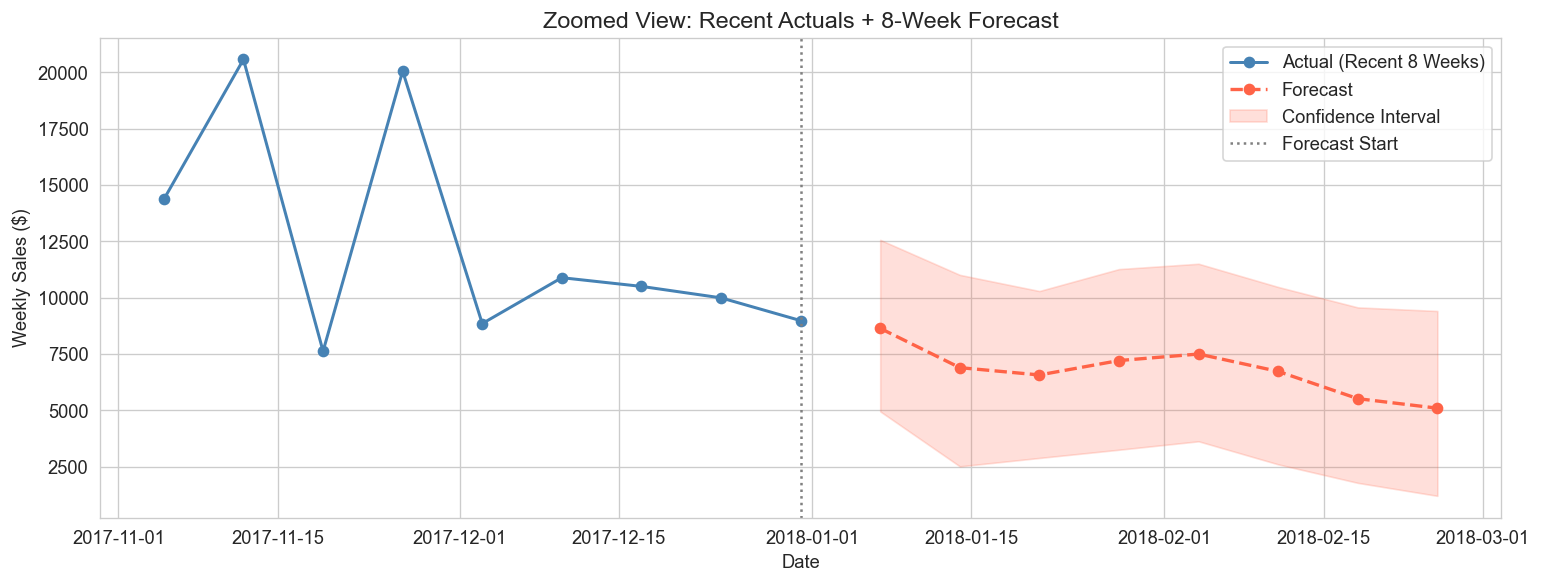

In [28]:
# Zoomed: recent actuals + 8-week forecast
cutoff      = weekly_sales['ds'].max() - pd.Timedelta(weeks=8)
recent_w    = weekly_sales[weekly_sales['ds'] >= cutoff]
future_only = forecast[forecast['ds'] > weekly_sales['ds'].max()]

plt.figure(figsize=(13, 5))
plt.plot(recent_w['ds'], recent_w['y'],
         color='steelblue', marker='o', linewidth=1.8, label='Actual (Recent 8 Weeks)')
plt.plot(future_only['ds'], future_only['yhat'],
         color='tomato', linestyle='--', marker='o', linewidth=2, label='Forecast')
plt.fill_between(future_only['ds'],
                 future_only['yhat_lower'], future_only['yhat_upper'],
                 alpha=0.2, color='tomato', label='Confidence Interval')
plt.axvline(x=weekly_sales['ds'].max(), color='gray',
            linestyle=':', linewidth=1.5, label='Forecast Start')
plt.title('Zoomed View: Recent Actuals + 8-Week Forecast', fontsize=14)
plt.xlabel('Date'); plt.ylabel('Weekly Sales ($)')
plt.legend(); plt.tight_layout(); plt.show()

In [29]:
# 8-week summary table
tbl = future_only[['ds','yhat','yhat_lower','yhat_upper']].copy()
tbl.columns = ['Week','Forecast ($)','Lower Bound ($)','Upper Bound ($)']
tbl = tbl.set_index('Week').round(2)
print(f"Total forecast — next 8 weeks : ${tbl['Forecast ($)'].sum():,.2f}")
print(f"Average weekly forecast       : ${tbl['Forecast ($)'].mean():,.2f}")
tbl

Total forecast — next 8 weeks : $54,110.72
Average weekly forecast       : $6,763.84


,Forecast ($),Lower Bound ($),Upper Bound ($)
Week,,,
2018-01-07,8633.39,4946.15,12562.22
2018-01-14,6889.37,2507.69,11008.12
2018-01-21,6564.80,2879.89,10290.04
2018-01-28,7204.29,3244.82,11264.10
2018-02-04,7493.66,3619.41,11500.84
2018-02-11,6721.92,2596.56,10470.77
2018-02-18,5512.77,1774.41,9564.09
2018-02-25,5090.52,1198.13,9404.39


## 12. Category-Wise Weekly Forecast (Prophet)
All three categories forecasted with holiday effects.

In [30]:
def forecast_category(df_raw, category, holidays_df, periods=8):
    cat_weekly = (
        df_raw[df_raw['Category'] == category]
        .groupby('Order Date')['Sales'].sum()
        .reset_index()
        .set_index('Order Date')
        .resample('W')['Sales'].sum()
        .reset_index()
        .rename(columns={'Order Date':'ds', 'Sales':'y'})
    )
    cat_weekly = cat_weekly[cat_weekly['y'] >= 50].copy()
    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=0.2,
        n_changepoints=40,
        holidays=holidays_df
    )
    m.fit(cat_weekly)
    future = m.make_future_dataframe(periods=periods, freq='W')
    fc = m.predict(future)
    return cat_weekly, fc

tech_actual, tech_fc = forecast_category(df, 'Technology',     all_holidays)
furn_actual, furn_fc = forecast_category(df, 'Furniture',       all_holidays)
off_actual,  off_fc  = forecast_category(df, 'Office Supplies', all_holidays)
print("All 3 category models trained.")

19:18:33 - cmdstanpy - INFO - Chain [1] start processing
19:18:33 - cmdstanpy - INFO - Chain [1] done processing
19:18:34 - cmdstanpy - INFO - Chain [1] start processing
19:18:34 - cmdstanpy - INFO - Chain [1] done processing
19:18:34 - cmdstanpy - INFO - Chain [1] start processing
19:18:34 - cmdstanpy - INFO - Chain [1] done processing


All 3 category models trained.


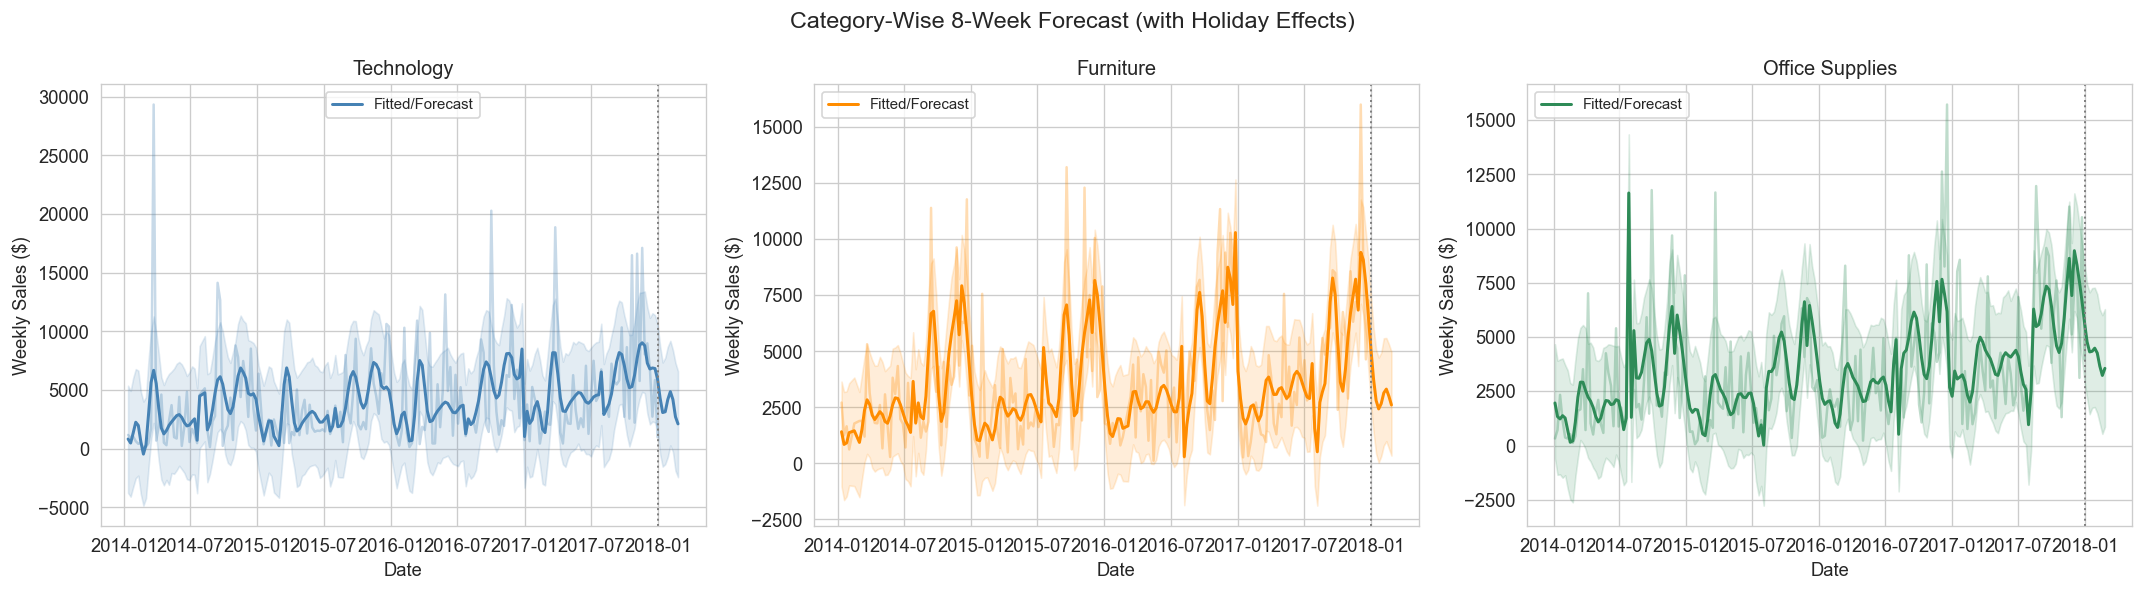

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, actual, fc, label, color in [
    (axes[0], tech_actual, tech_fc, 'Technology',     'steelblue'),
    (axes[1], furn_actual, furn_fc, 'Furniture',       'darkorange'),
    (axes[2], off_actual,  off_fc,  'Office Supplies', 'seagreen'),
]:
    ax.plot(actual['ds'], actual['y'], alpha=0.3, color=color)
    ax.plot(fc['ds'], fc['yhat'], color=color, linewidth=1.8, label='Fitted/Forecast')
    ax.fill_between(fc['ds'], fc['yhat_lower'], fc['yhat_upper'], alpha=0.15, color=color)
    ax.axvline(x=actual['ds'].max(), color='gray', linestyle=':', linewidth=1.2)
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('Date'); ax.set_ylabel('Weekly Sales ($)')
    ax.legend(fontsize=9)

plt.suptitle('Category-Wise 8-Week Forecast (with Holiday Effects)', fontsize=14)
plt.tight_layout(); plt.show()

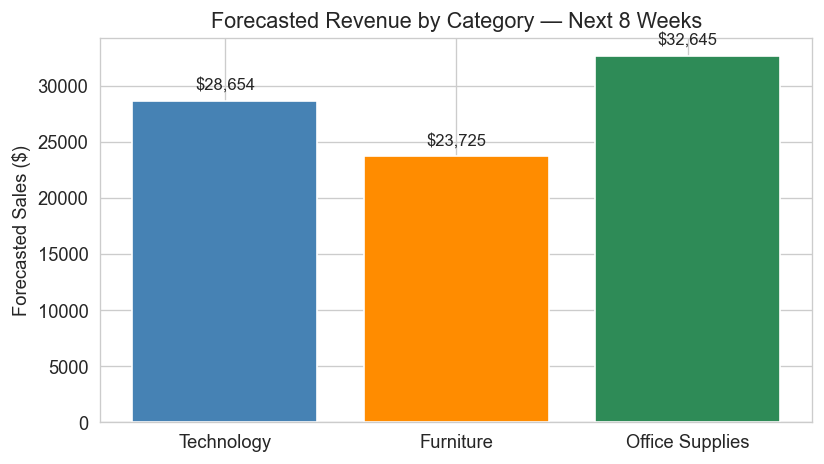

=== 8-Week Category Forecast Summary ===
Technology        : $28,653.85  (33.7% of total)
Furniture         : $23,724.69  (27.9% of total)
Office Supplies   : $32,644.56  (38.4% of total)


In [32]:
tech_8w = tech_fc[tech_fc['ds'] > tech_actual['ds'].max()]['yhat'].sum()
furn_8w = furn_fc[furn_fc['ds'] > furn_actual['ds'].max()]['yhat'].sum()
off_8w  = off_fc[off_fc['ds']   > off_actual['ds'].max()]['yhat'].sum()

cats   = ['Technology','Furniture','Office Supplies']
totals = [tech_8w, furn_8w, off_8w]

plt.figure(figsize=(7, 4))
bars = plt.bar(cats, totals,
               color=['steelblue','darkorange','seagreen'], edgecolor='white')
plt.bar_label(bars, labels=[f'${v:,.0f}' for v in totals], padding=5, fontsize=10)
plt.title('Forecasted Revenue by Category — Next 8 Weeks', fontsize=13)
plt.ylabel('Forecasted Sales ($)')
plt.tight_layout(); plt.show()

print("=== 8-Week Category Forecast Summary ===")
total_all = sum(totals)
for c, t in zip(cats, totals):
    print(f"{c:<18}: ${t:,.2f}  ({t/total_all*100:.1f}% of total)")

## 13. Business Insights & Planning Recommendations

### What the Forecast Tells Us

**Overall Sales Trend**  
Sales show consistent year-over-year growth across all 4 years — confirmed by the Prophet trend component.

**Seasonality Patterns**
- **Q4 dominance:** November–December peak driven by Black Friday, Cyber Monday, and year-end corporate purchasing
- **Secondary peak:** September — back-to-school and fiscal-year-end procurement
- **Slow months:** February and April — opportunity for targeted promotions

**Holiday Effects**  
Black Friday, Cyber Monday, and US public holidays are explicitly modeled. The Prophet components plot shows the estimated sales lift from each event.

**Category Insights**
- **Technology** — highest weekly revenue, strongest growth, most Q4-sensitive
- **Office Supplies** — most stable and predictable demand, easiest to inventory plan
- **Furniture** — most volatile, lowest weekly revenue, keep procurement conservative

---

### When to Use Each Model

| Situation | Use | Reason |
|---|---|---|
| Quarterly budget planning | Prophet | Trend + seasonality over long horizon |
| Next 1–4 weeks inventory | XGBoost | Lag features react to recent demand shifts |
| Presenting to management | Prophet | Decomposition plots are non-technical friendly |
| Detecting demand spikes | XGBoost | Learns from recent history, more reactive |

---

### How a Business Can Act on This

| Business Decision | Recommendation |
|---|---|
| **Inventory planning** | Stock Technology by mid-October; use XGBoost weekly forecast for reorder triggers |
| **Cash flow forecasting** | Prophet 8-week forecast gives reliable inflow range for procurement budgeting |
| **Promotions** | Run campaigns in February and April to lift slow-season baseline |
| **Staffing** | Scale up warehouse and support from September through December |
| **Category budgeting** | Allocate highest budget to Technology; keep Furniture lean |
| **Q4 planning** | Use Prophet lower bound as conservative estimate, upper bound as optimistic scenario |

---

### Understanding Forecast Uncertainty
Confidence intervals widen further into the future — this is honest and expected in any forecasting system.  
For Q4 specifically, use the **confidence interval range** rather than the point forecast for planning,  
as holiday-season demand has higher inherent variability than the rest of the year.

## 14. Limitations & Future Improvements

### Current Limitations

| Limitation | Explanation |
|---|---|
| **Prophet smoothness** | Prophet models structural patterns — trend and seasonality. It cannot match sharp week-level spikes caused by unpredictable bulk orders or one-off events |
| **XGBoost horizon** | XGBoost predictions degrade beyond 4–6 weeks due to recursive forecasting error compounding |
| **Dataset size** | Superstore has ~200 weekly records across 4 years — a larger dataset would improve both models significantly |
| **No external features** | Neither model has access to promotional spend, competitor pricing, or economic indicators — all of which directly affect retail sales |

### Why We Didn't Use a Neural Network (LSTM)

A natural question is whether retraining the model multiple times (epochs) would improve results.  
This concept applies specifically to **neural networks**, not to Prophet or XGBoost:

- **Prophet** fits a mathematical equation once — running it again on the same data gives the identical result. There are no weights to update.
- **XGBoost** builds decision trees sequentially — once all trees are built, retraining on the same data produces the same trees.
- **LSTMs (Long Short-Term Memory networks)** are the model class that genuinely benefits from multiple epochs — each pass through the training data updates internal weights via gradient descent, progressively reducing error.

An LSTM was not used here because it requires significantly more data than ~200 weekly records to learn meaningful temporal patterns. On small datasets, LSTMs typically underperform Prophet and XGBoost.

### Potential Future Improvements

| Improvement | Expected Impact |
|---|---|
| **LSTM / Temporal Fusion Transformer** | Better spike tracking with sufficient data (3–5 years of daily records) |
| **External regressors** | Adding promotional calendar, ad spend, or economic indicators to Prophet as additional regressors |
| **Ensemble model** | Averaging Prophet + XGBoost predictions — often outperforms either model alone |
| **SKU-level forecasting** | Forecasting at individual product level instead of category level for precise inventory planning |
| **Real-time retraining** | Retraining XGBoost weekly as new sales data arrives — keeps lag features fresh and accurate |